In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
import Inference as inf

In [2]:
import sys
from src import dataloader

In [3]:
MIN_EXTREME_VALUE_Threshold = 22.24
Max_EXTREME_VALUE_Threshold = 54.36

### Return 10th, 50th, and 90th of keywords in training dataset

In [4]:
data_loader_training, data_loader_validate, data_loader_test = dataloader.get_dataloaders(
    batch_size = 1, 
    img_size = 16,
    in_channels = 8, 
    resmapling_status = False,
    data = 's2',
    exp_name = 'sensitivity'
    )

(13875, 36) | (8233, 36) | (12443, 36)


In [5]:
# Example keywords to extract
# keywords = ['soil texture', 'pH', 'electrical conductivity', 'calcium', 'magnesium', 
#             'sodium', 'exchangeable sodium percentage', 'boron', 'nitrate nitrogen', 
#             'phosphate phosphorus', 'potassium', 'zinc', 'manganese', 'iron', 'copper', 'organic matter']

keywords = ['pH', 'electrical conductivity', 'potassium', 'manganese']

keywords_dict = inf.process_texts(data_loader_training, keywords)
for keyword, percentile_values in keywords_dict.items():
    print(f"{keyword}:")
    # Collect percentiles in the desired format
    formatted_percentiles = " | ".join([f"{percentile}: {value}" for percentile, value in percentile_values.items()])
    print(f"  {formatted_percentiles}")

pH:
  0th: 5.7 | 10th: 5.8 | 20th: 5.8 | 30th: 5.8 | 40th: 7.1 | 50th: 7.1 | 60th: 7.4 | 70th: 7.4 | 80th: 7.6 | 90th: 7.8 | 100th: 8.2
electrical conductivity:
  0th: 0.3 | 10th: 0.6 | 20th: 0.6 | 30th: 1.04 | 40th: 1.09 | 50th: 1.09 | 60th: 1.58 | 70th: 5.01 | 80th: 7.2 | 90th: 7.2 | 100th: 9.03
potassium:
  0th: 27.0 | 10th: 27.0 | 20th: 59.0 | 30th: 63.0 | 40th: 65.0 | 50th: 70.0 | 60th: 70.0 | 70th: 125.0 | 80th: 125.0 | 90th: 194.0 | 100th: 647.0
manganese:
  0th: 2.0 | 10th: 2.0 | 20th: 2.2 | 30th: 2.3 | 40th: 3.7 | 50th: 3.7 | 60th: 4.8 | 70th: 12.0 | 80th: 12.0 | 90th: 12.0 | 100th: 15.5


### Analysis

In [6]:
E003 = '003_full_vit_768_8_6_8_30_0001_01_32_init01_ts'

In [ ]:
for keyword, percentile_values in keywords_dict.items():
    # Loop through 10th, 50th, and 90th percentiles
    for percentile, value in percentile_values.items():
        # Skip if the value is None
        if value is None:
            continue
        inf_dataloader = dataloader.sns_inference_dataloader(batch_size = 64, 
                                    exp_name = E003, 
                                    keyword = keyword, 
                                    new_avlue = value)

        inf.predict(inf_dataloader, exp_name= E003, keyword= keyword, new_value = value)

### Visualization

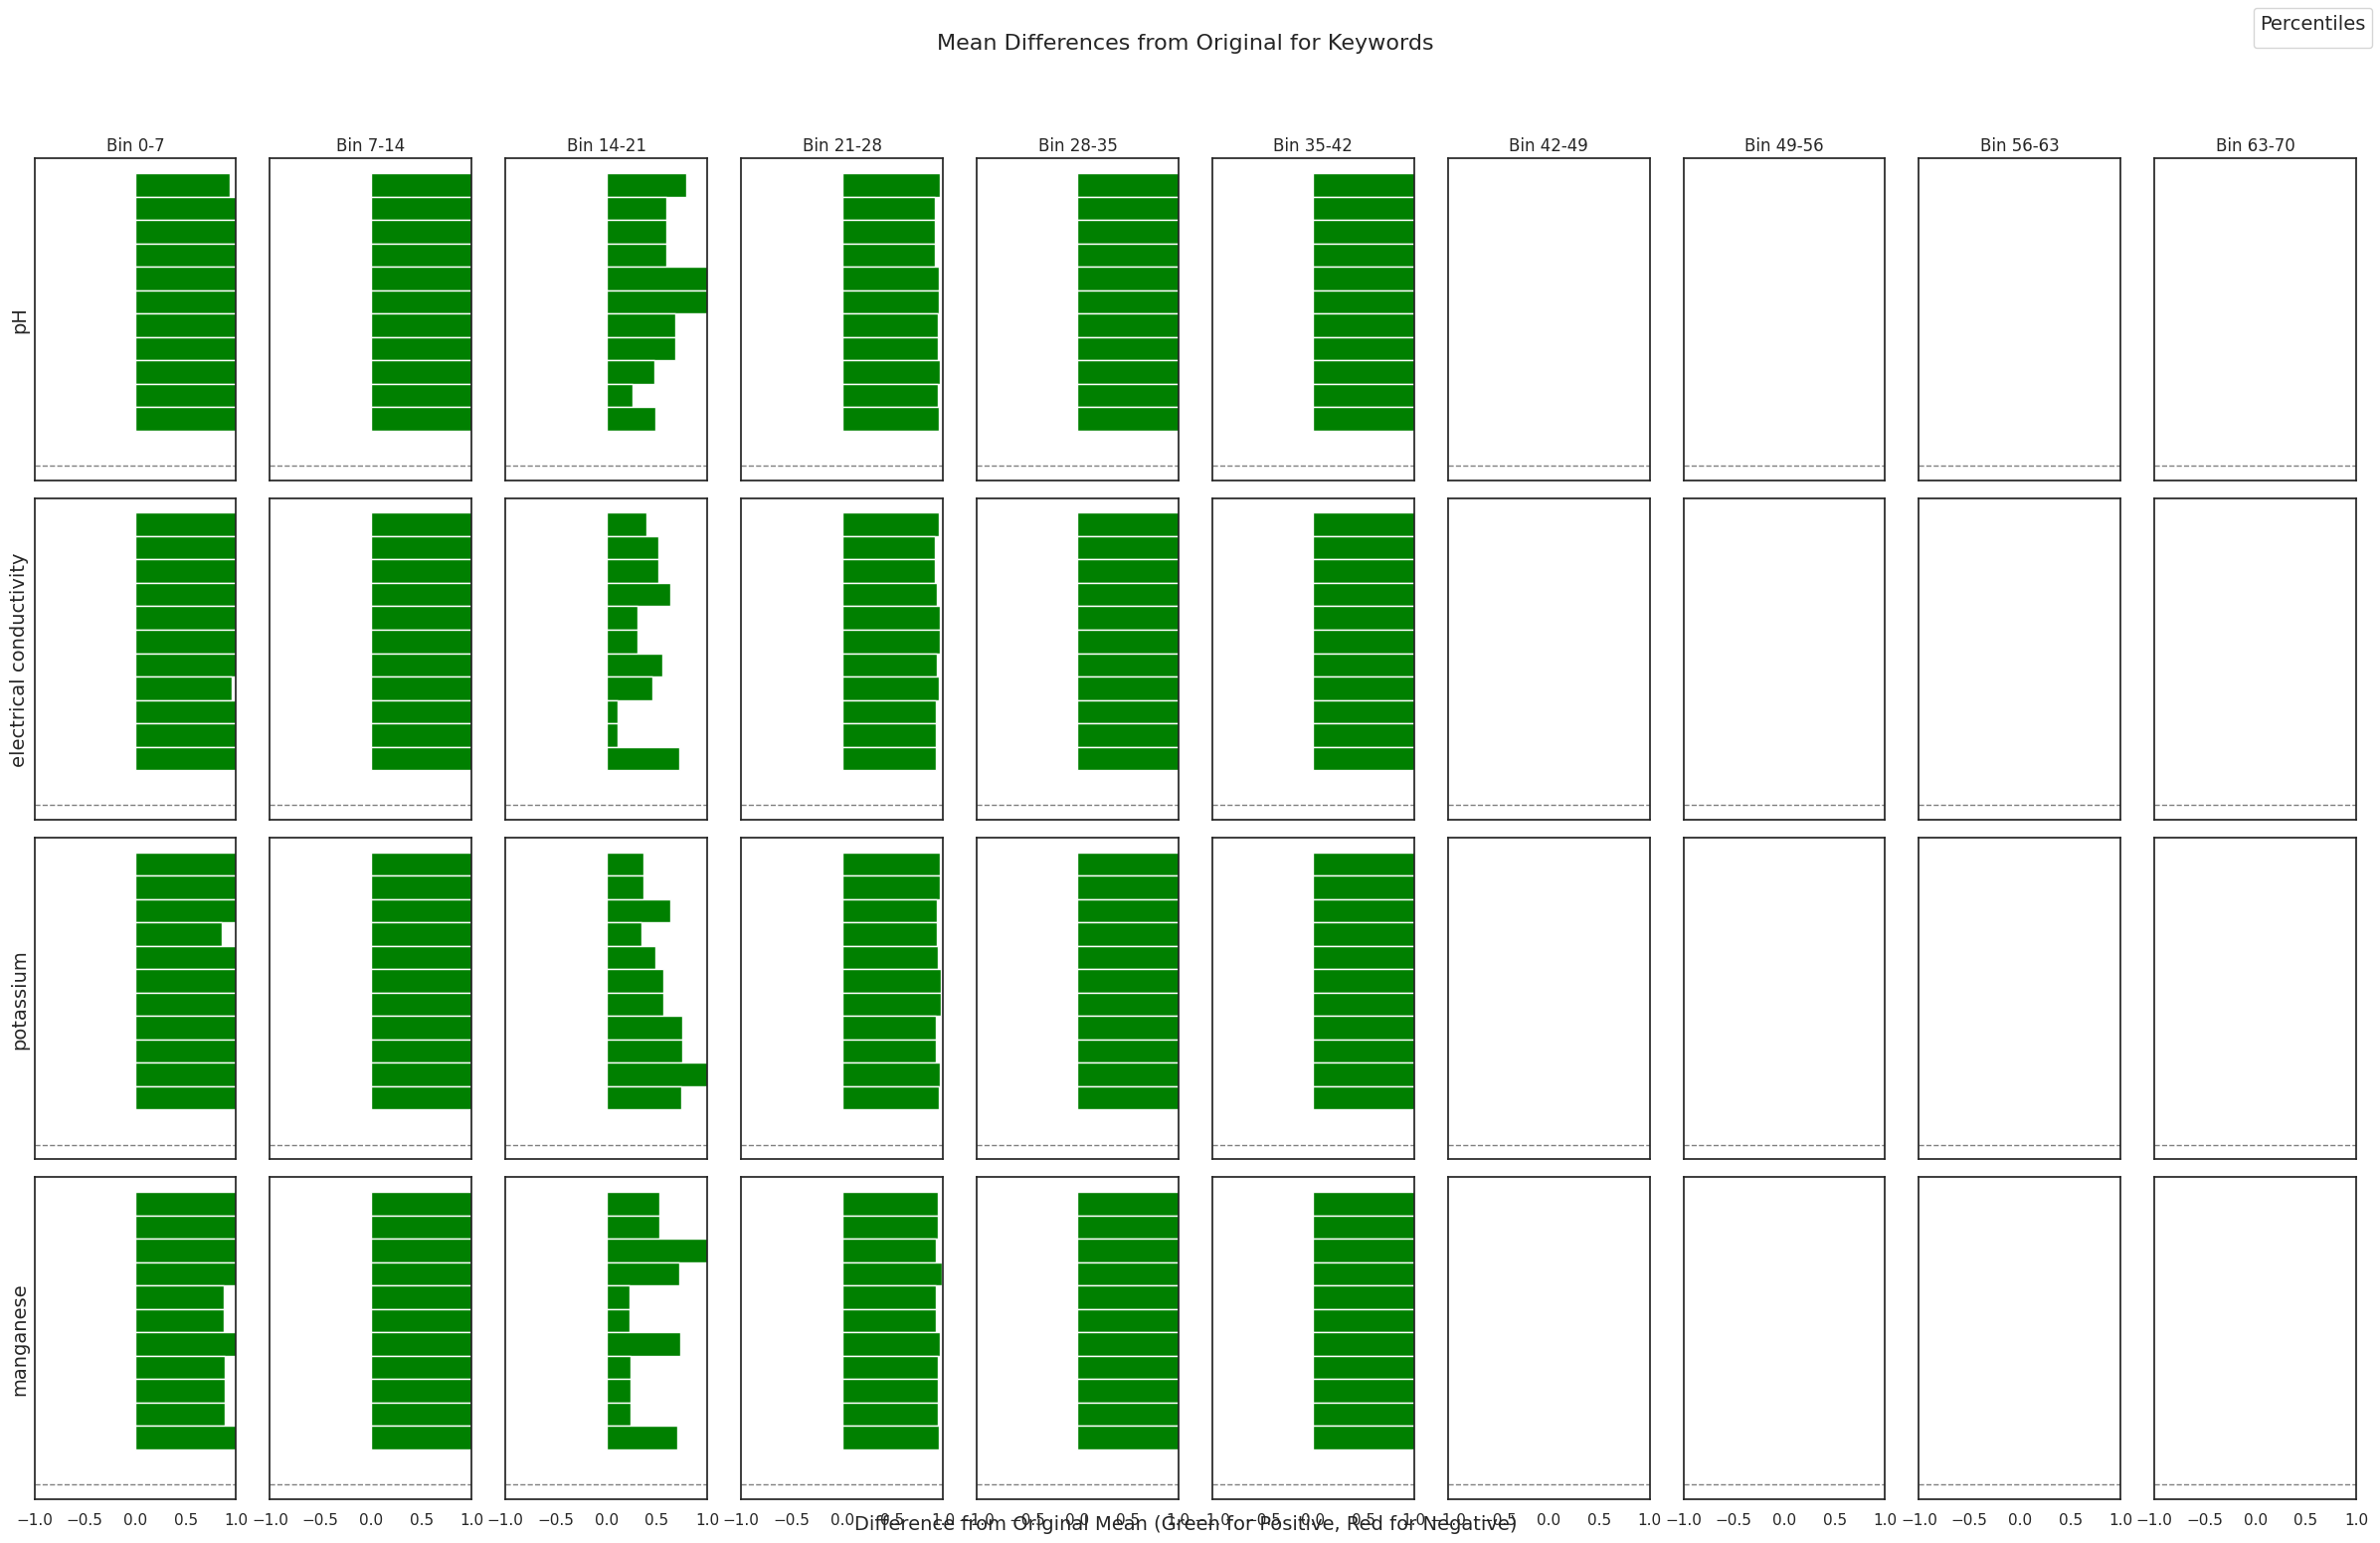

In [7]:
inf.plot_mean_difference(exp_name = E003, 
                         keywords_dict = keywords_dict, 
                         block  = 1352018)

In [9]:
import pandas as pd
df = pd.read_csv('/data2/hkaman/Projects/ViT/EXPs/Sep/EXP_002_s12mettext_vit_768_8_6_8_30_0001_01_64_init01/002_s12mettext_vit_768_8_6_8_30_0001_01_64_init01_test.csv')
df['block'].unique()

array([ 902016, 1862016,  252018,   52016, 1862017, 1052017,   52018,
       1142016,  262017,  252019, 1142019, 1812017, 1812018, 1782018,
        112016, 1352017, 1782016,  252016,  902017,  112018, 1782019,
       1812016,  112017, 1932017, 1352018,  622016,  902019, 1782017,
        262016, 1052016, 1812019, 1862019, 1052019,  252017, 1052018,
        112019, 1142018, 1352016, 1352019,  622018,  622017, 1142017,
       1862018,  902018,   52017])

In [7]:
modified_dict = dict(list(keywords_dict.items())[:2])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


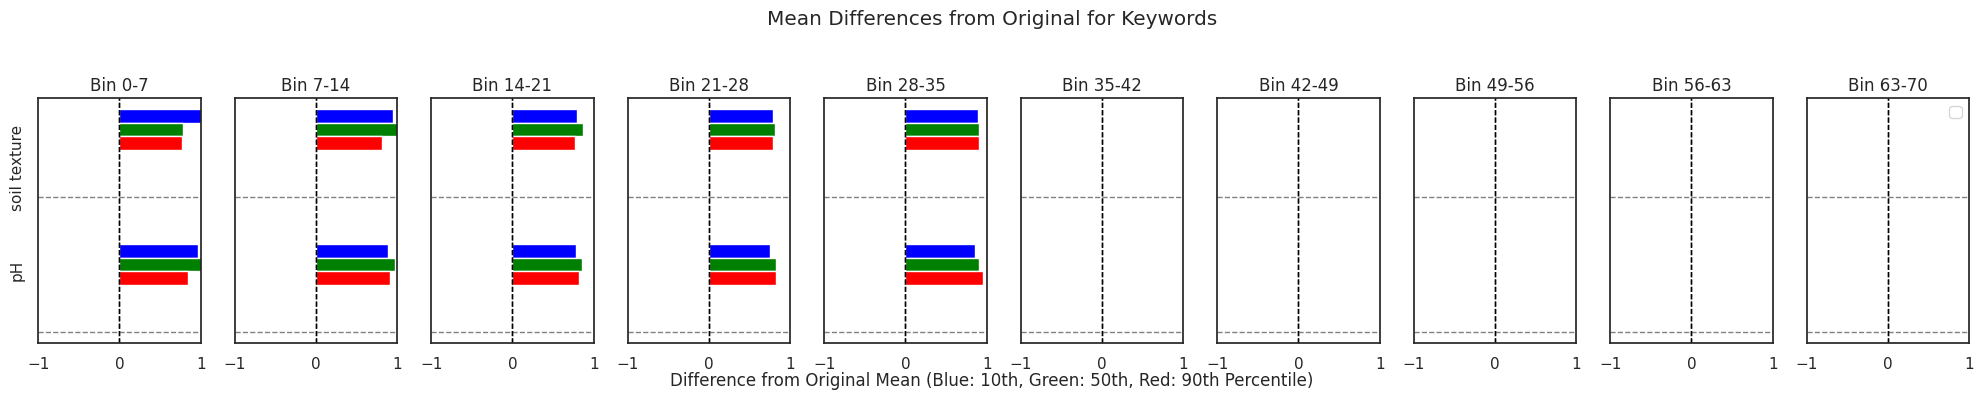

In [9]:
inf.plot_mean_difference(exp_name = E003, 
                         keywords_dict = modified_dict, 
                         block  = 622016)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


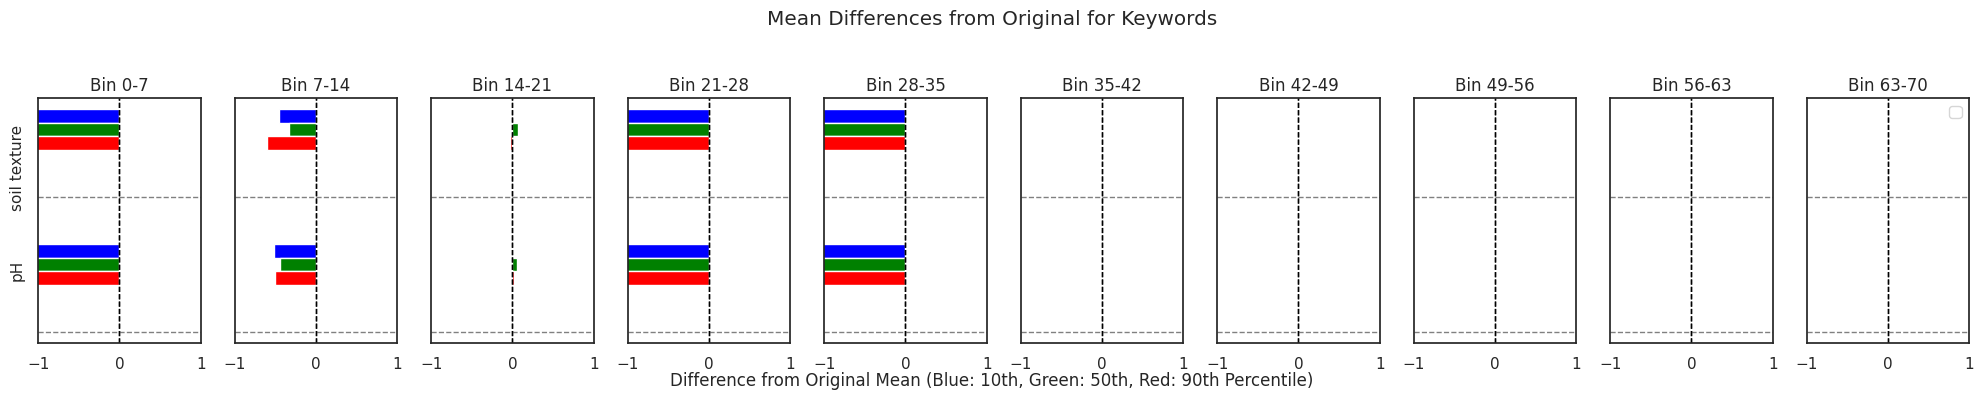

In [25]:
inf.plot_mean_difference(exp_name = E003, 
                         keywords_dict = modified_dict, 
                         block  = 622016)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


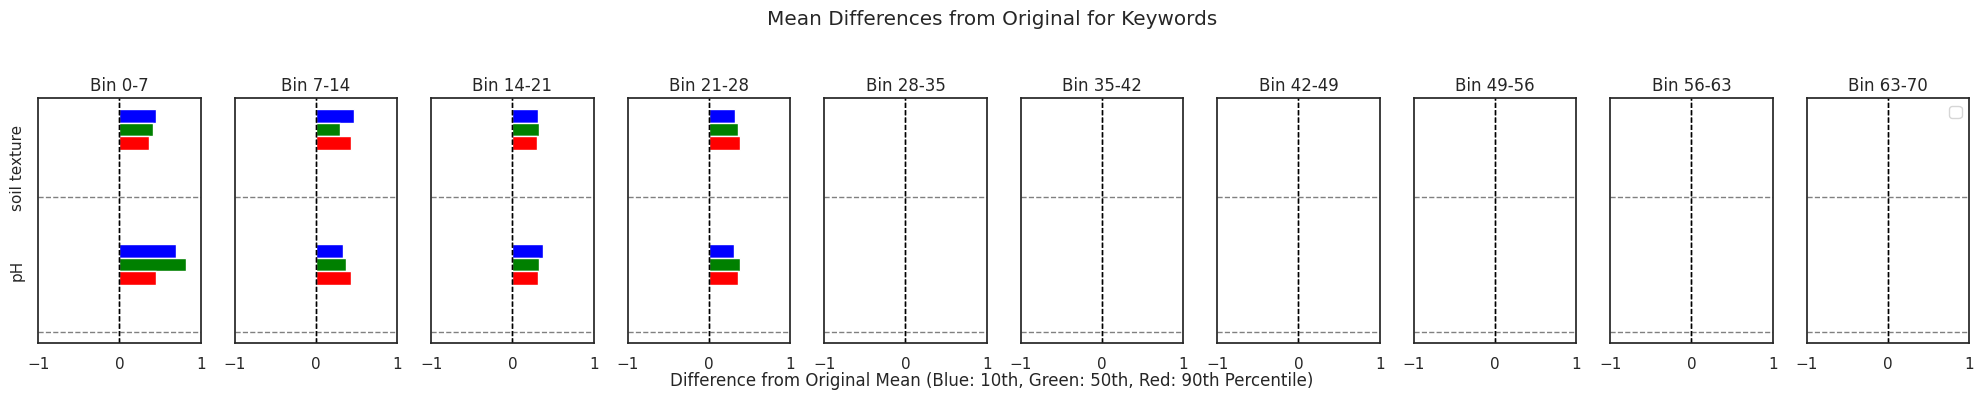

In [10]:
inf.plot_mean_difference(exp_name = E003, 
                         keywords_dict = modified_dict, 
                         block  = 112018)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


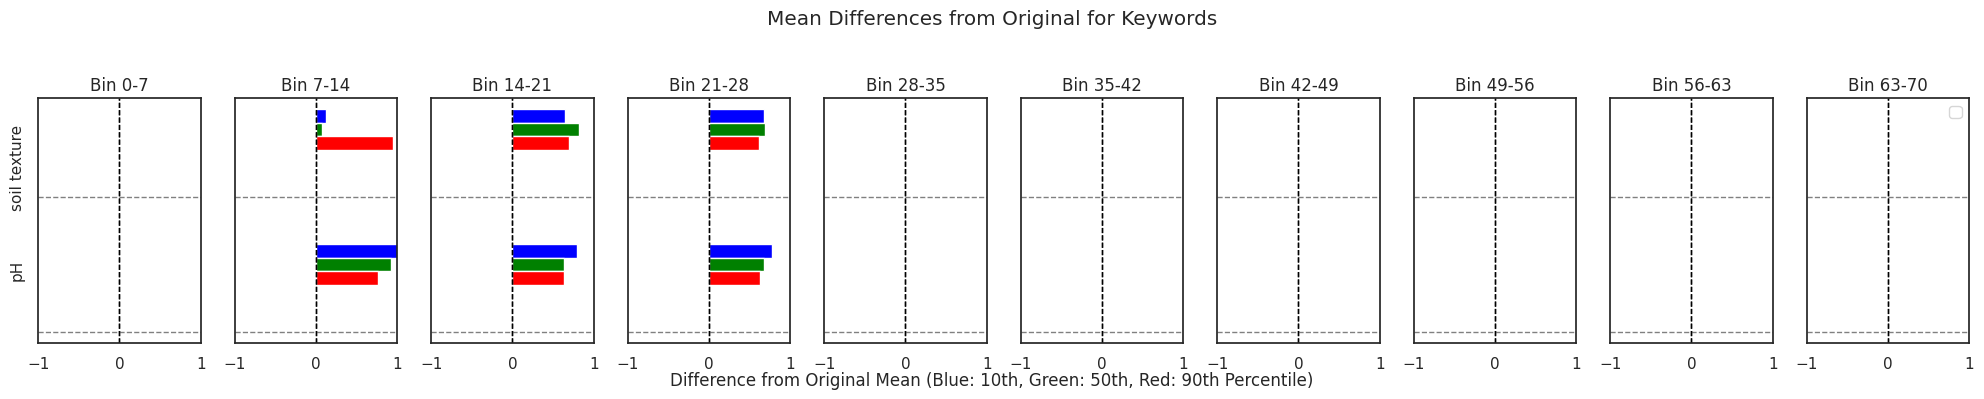

In [11]:
inf.plot_mean_difference(exp_name = E003, 
                         keywords_dict = modified_dict, 
                         block  = 262017)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


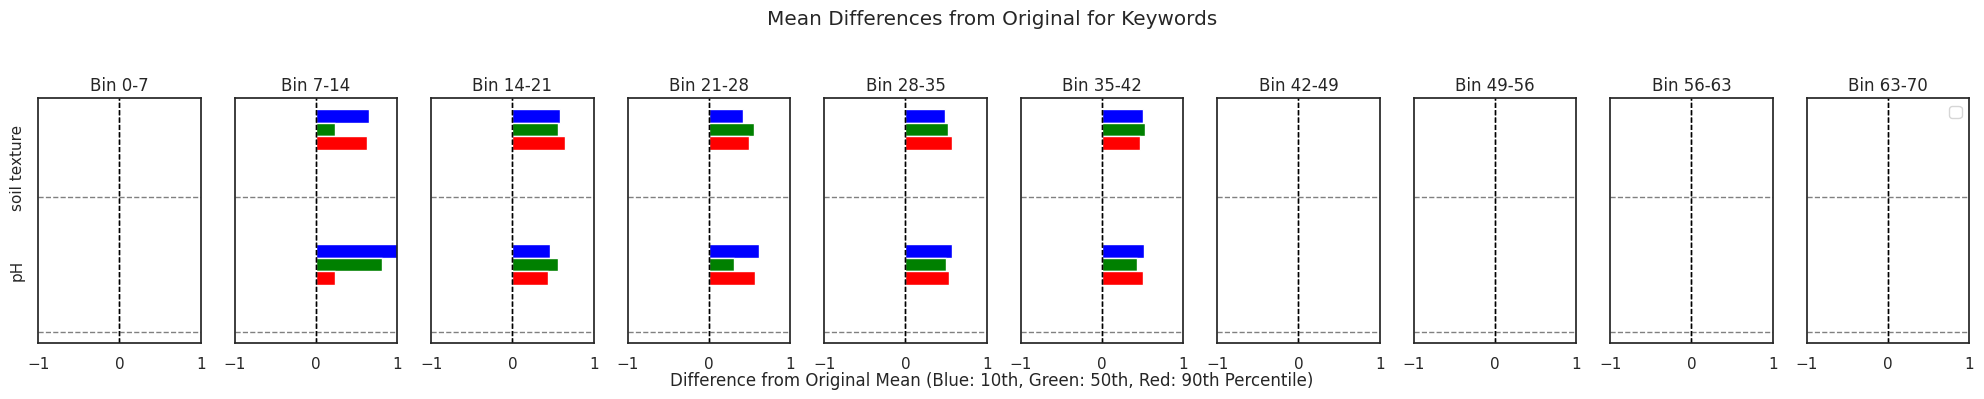

In [12]:
inf.plot_mean_difference(exp_name = E003, 
                         keywords_dict = modified_dict, 
                         block  = 52018)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


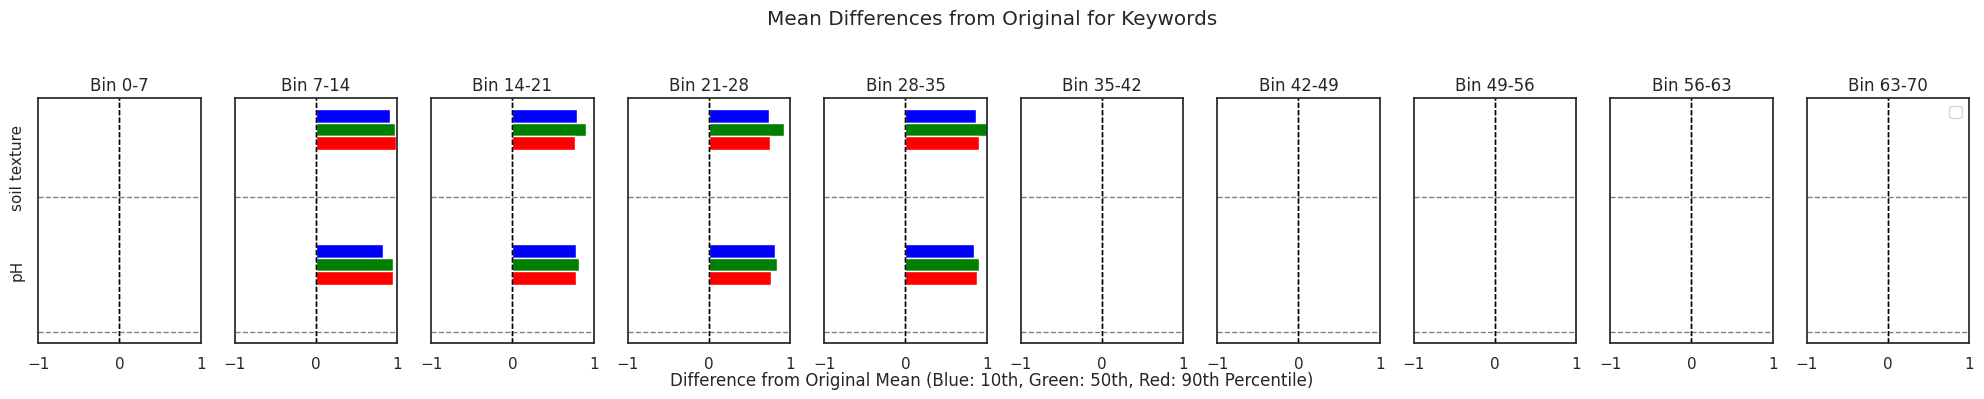

In [13]:
inf.plot_mean_difference(exp_name = E003, 
                         keywords_dict = modified_dict, 
                         block  = 902016)

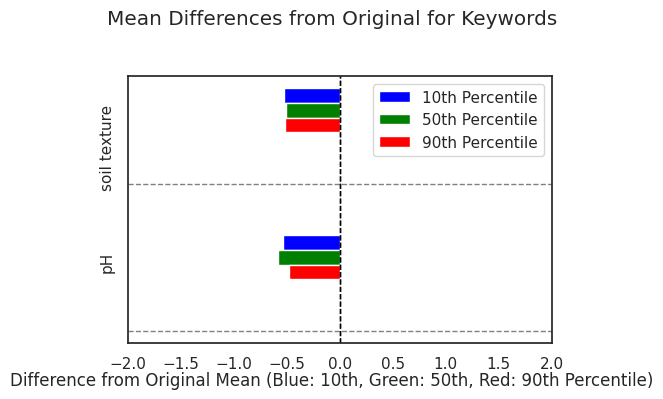

In [38]:
inf.plot_mean_difference_blocklevel(exp_name = E003, 
                         keywords_dict = modified_dict, 
                         block  = 1352018)

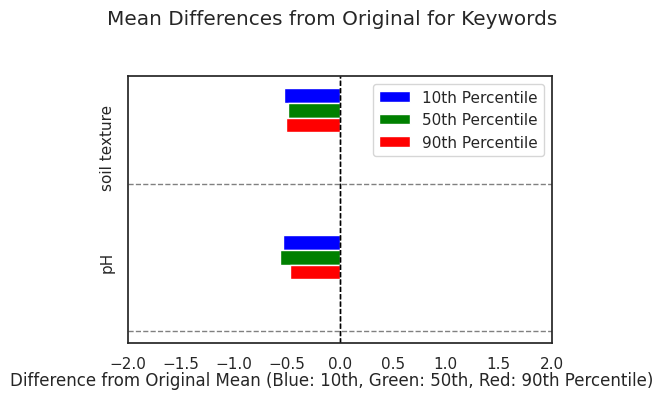

In [37]:
inf.plot_mean_difference_blocklevel(exp_name = E003, 
                         keywords_dict = modified_dict, 
                         block  = 1352018)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


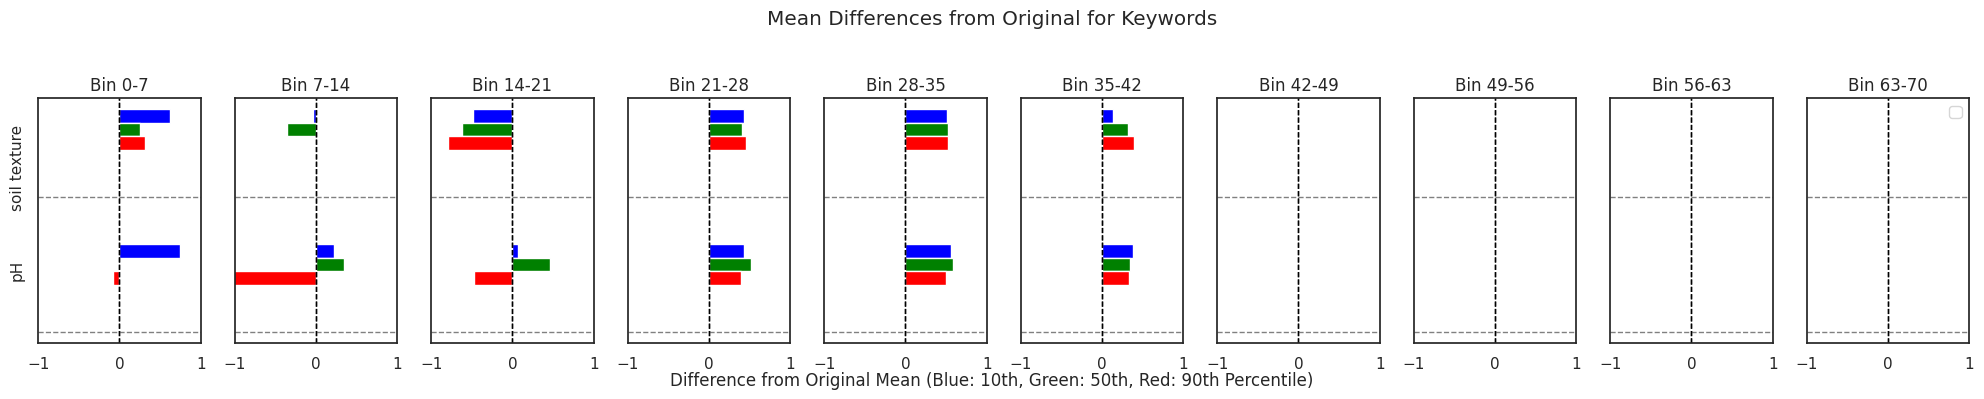

In [14]:
inf.plot_mean_difference(exp_name = E003, 
                         keywords_dict = modified_dict, 
                         block  = 1352018)

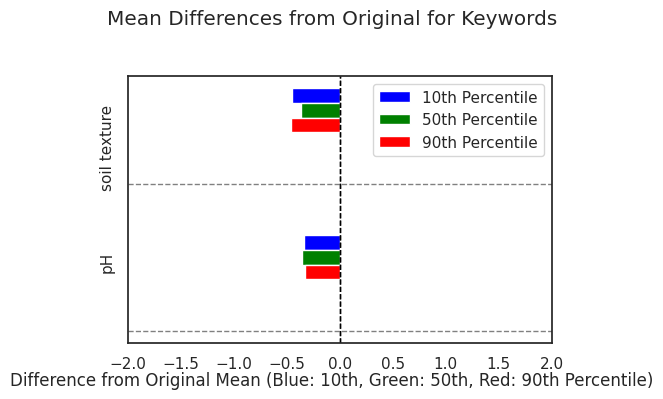

In [39]:
inf.plot_mean_difference_blocklevel(exp_name = E003, 
                         keywords_dict = modified_dict, 
                         block  = 1862016)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


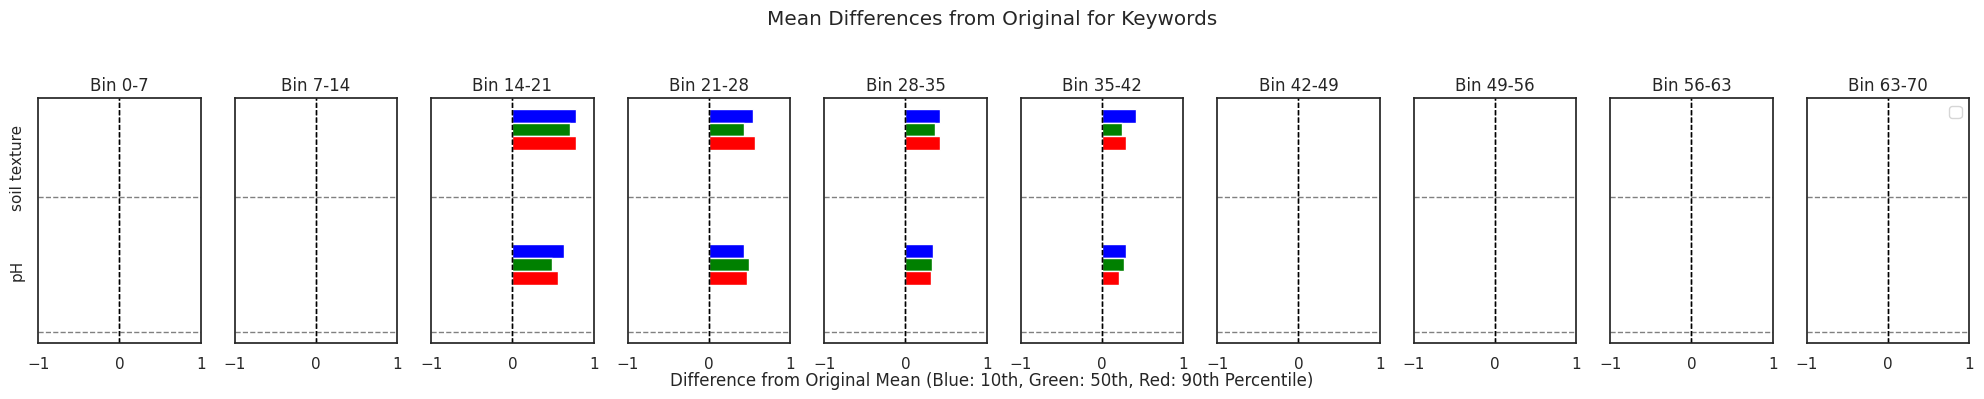

In [15]:
inf.plot_mean_difference(exp_name = E003, 
                         keywords_dict = modified_dict, 
                         block  = 1862016)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


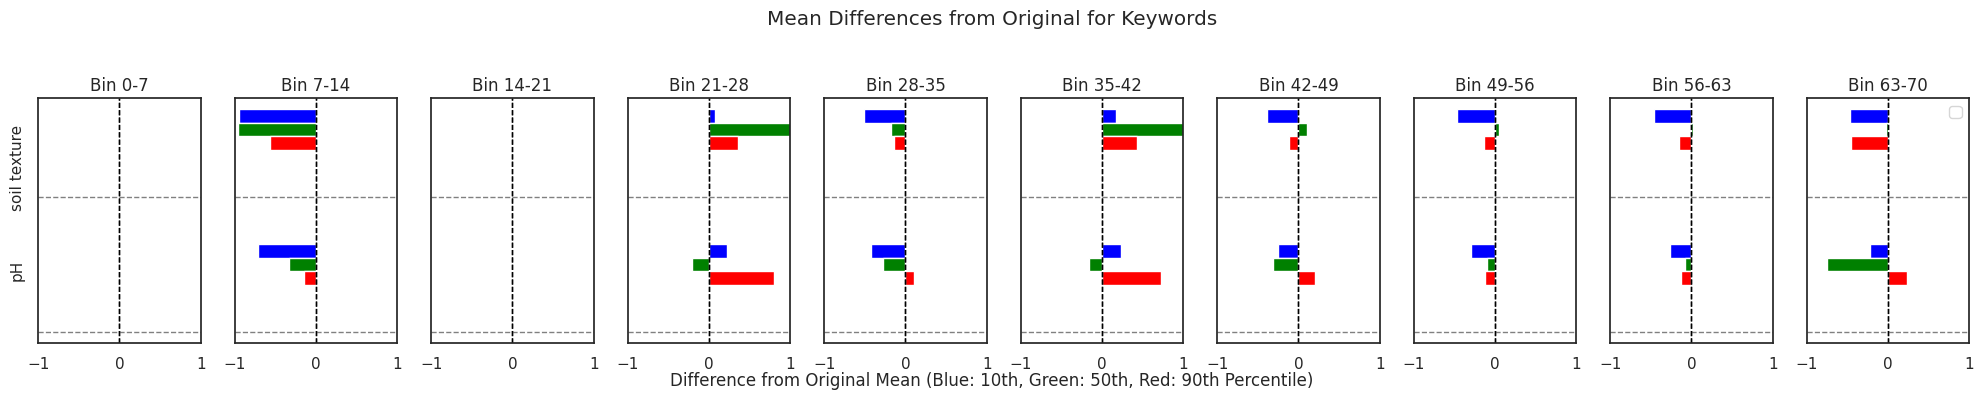

In [43]:
inf.plot_mean_difference(exp_name = E003, 
                         keywords_dict = modified_dict, 
                         block  = 1812019)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


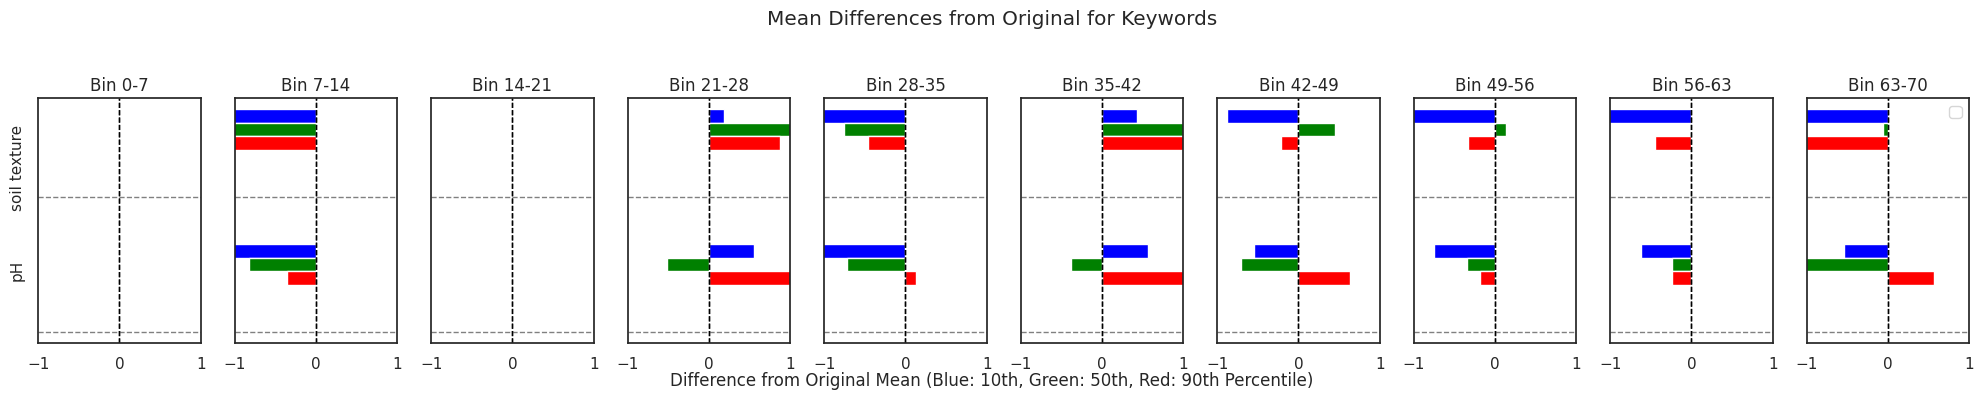

In [16]:
inf.plot_mean_difference(exp_name = E003, 
                         keywords_dict = modified_dict, 
                         block  = 1812019)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


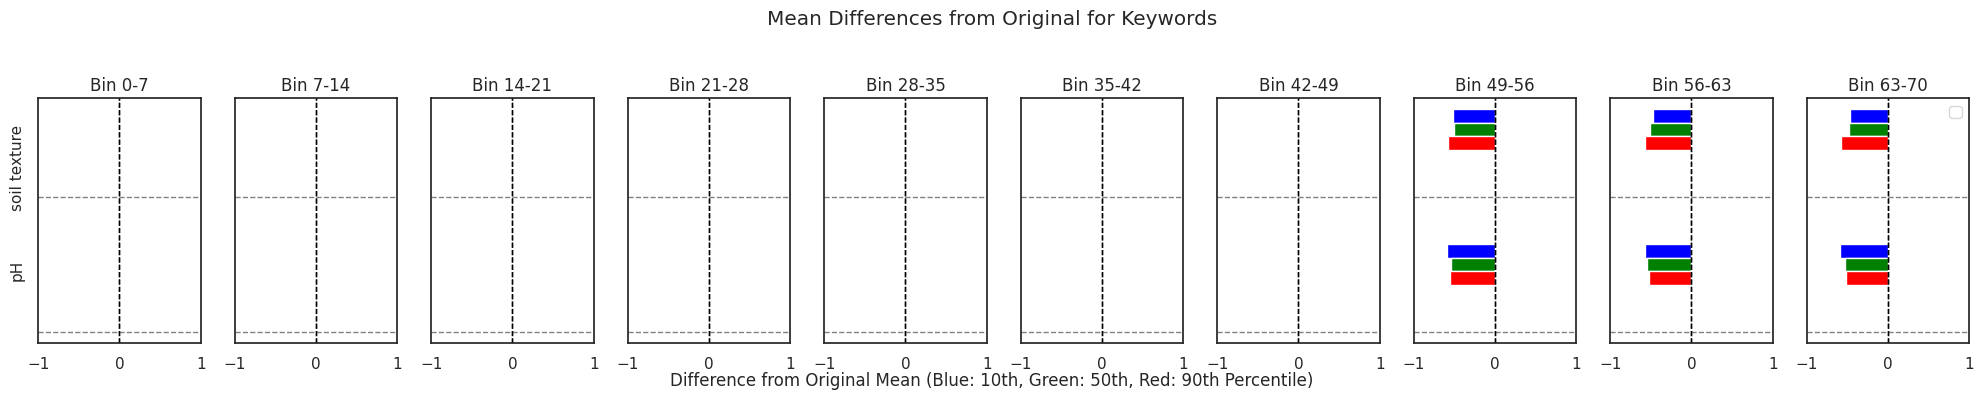

In [44]:
inf.plot_mean_difference(exp_name = E003, 
                         keywords_dict = modified_dict, 
                         block  = 1812017)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


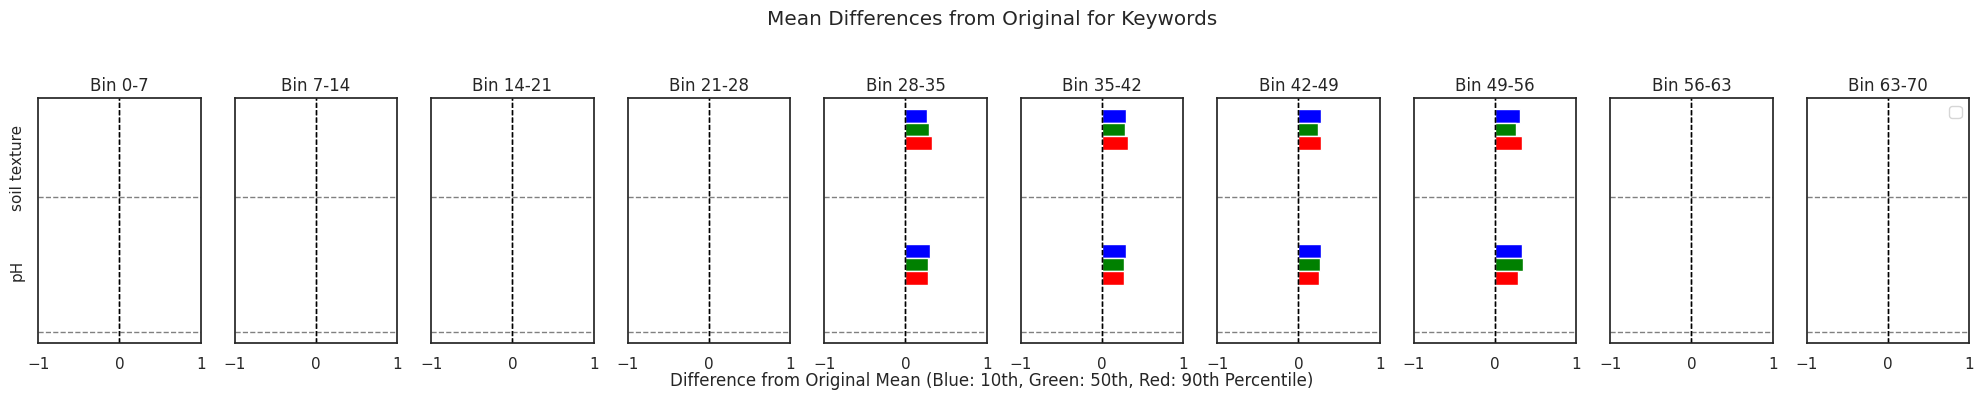

In [45]:
inf.plot_mean_difference(exp_name = E003, 
                         keywords_dict = modified_dict, 
                         block  = 1782017)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


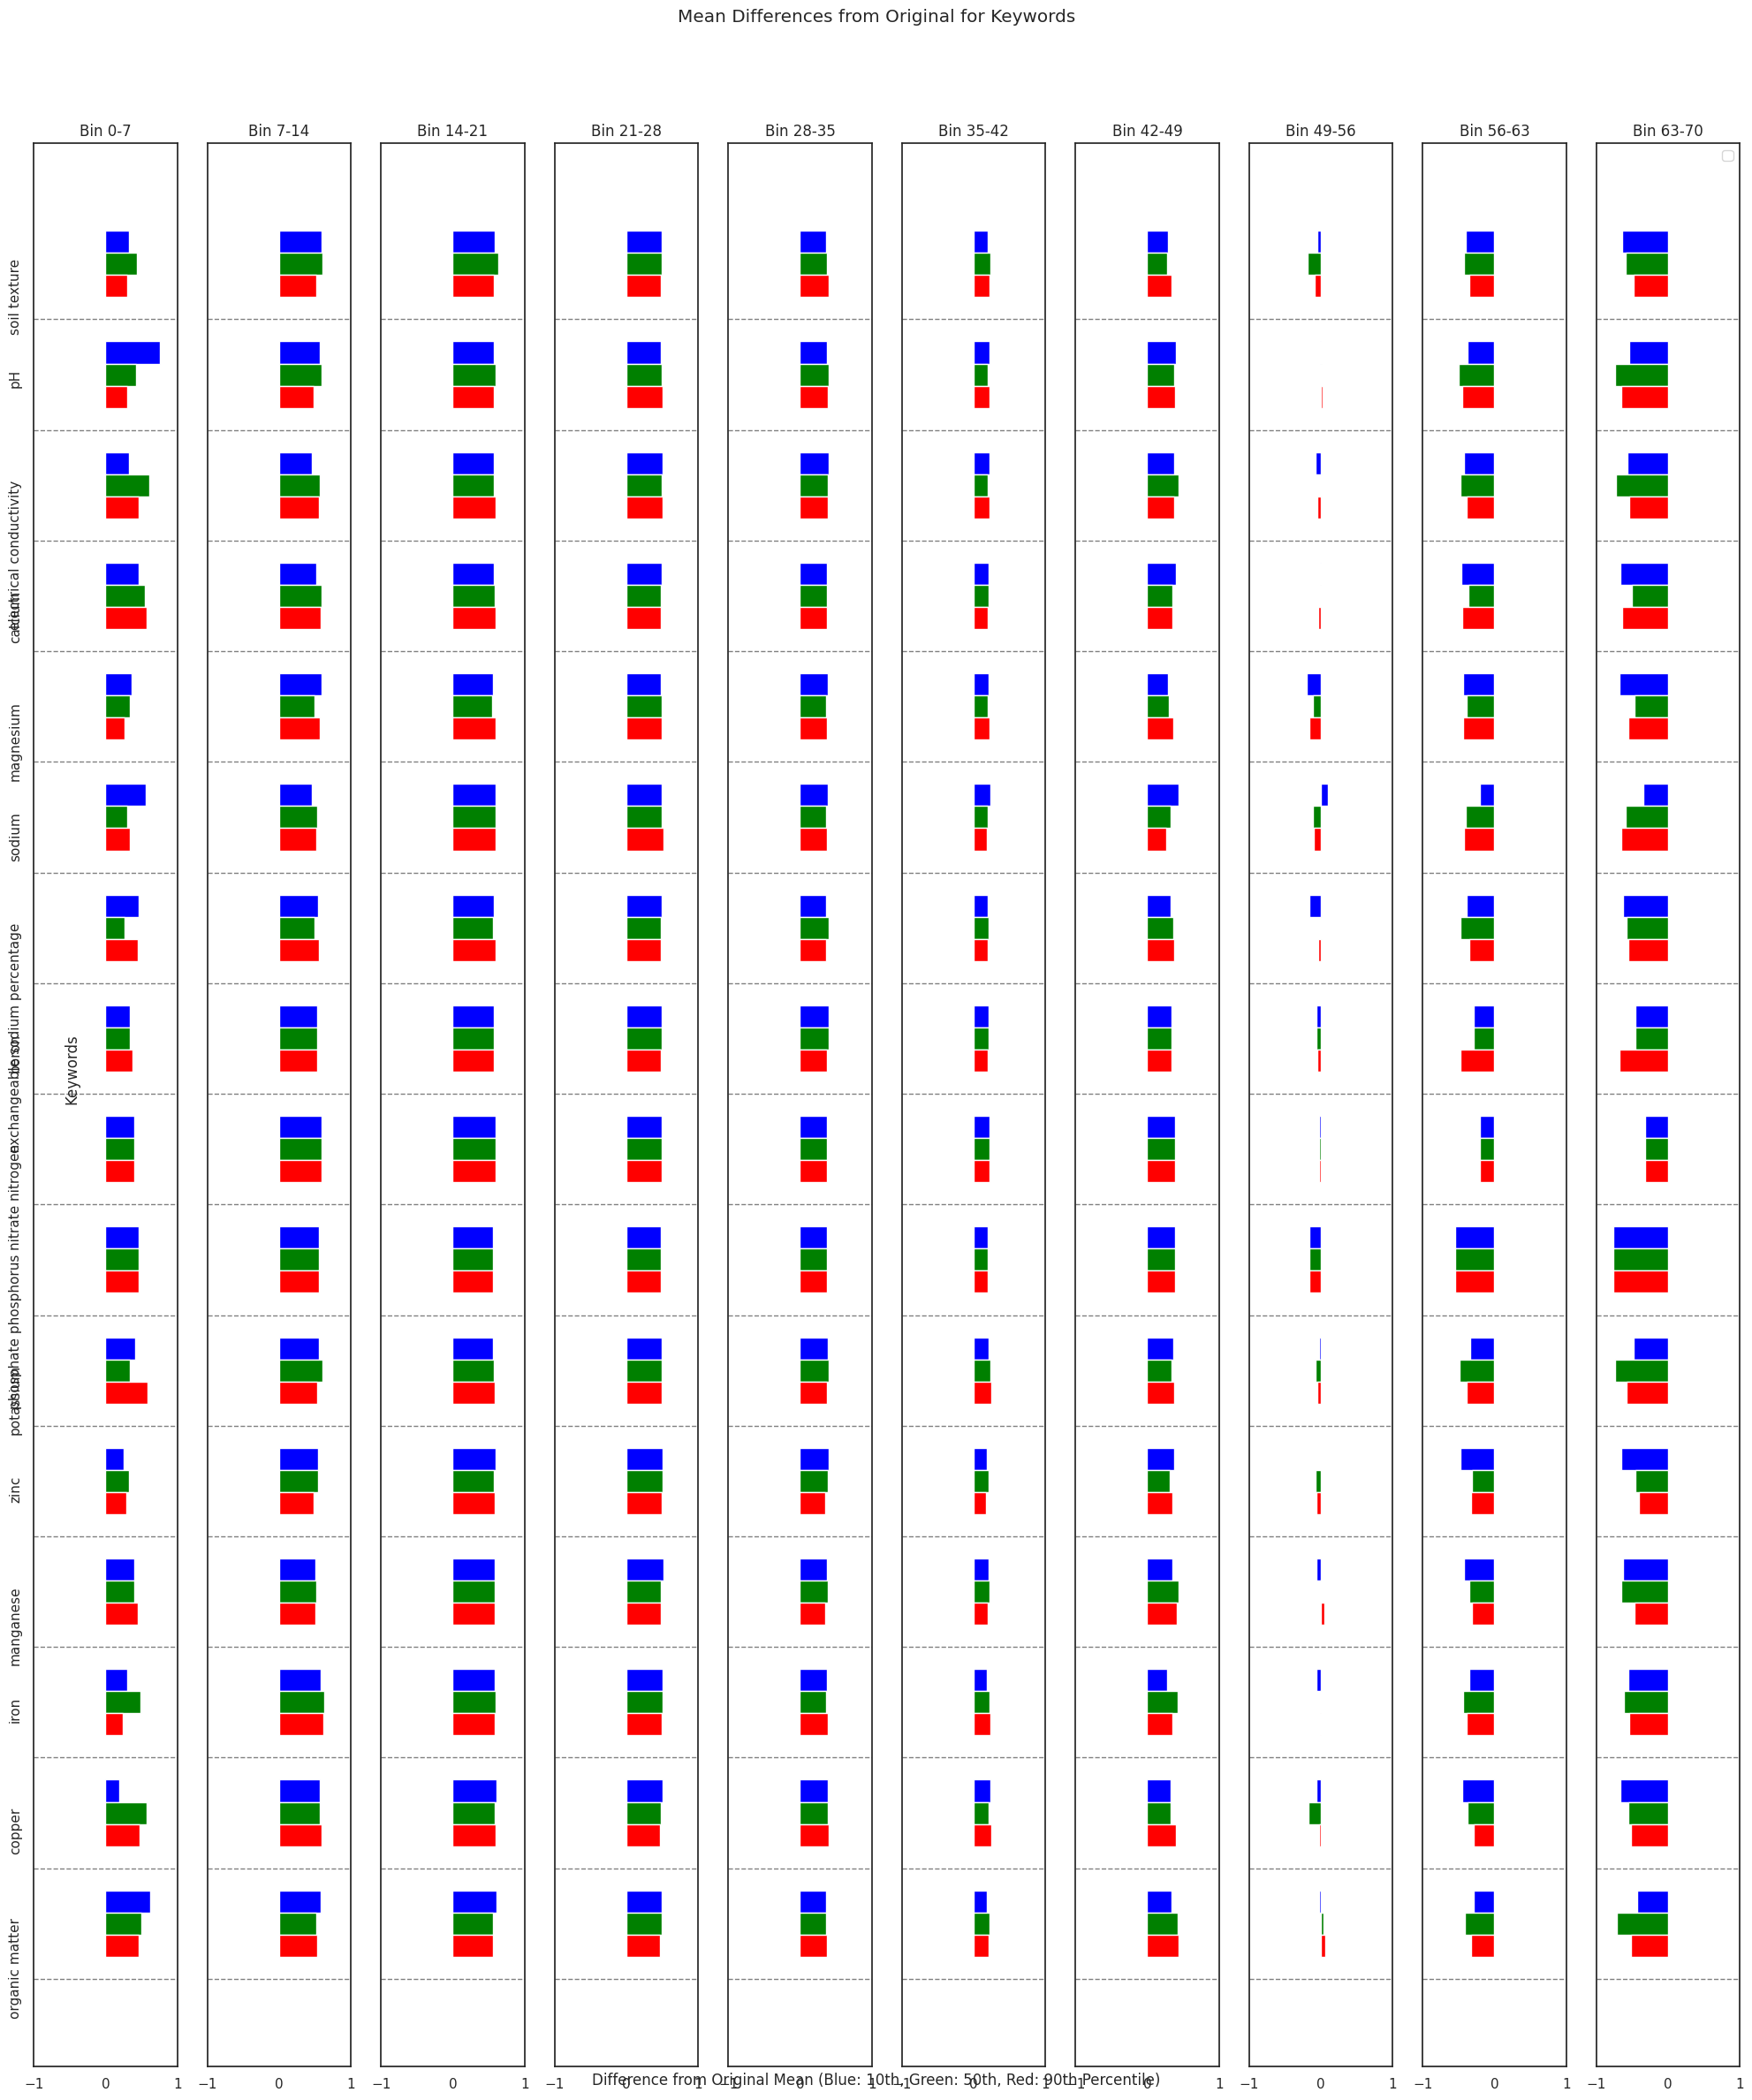

In [61]:
inf.plot_mean_difference(exp_name = E003, 
                         keywords_dict = keywords_dict)